In [165]:
import pandas as pd
import numpy as np
import mysql.connector as sql
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

In [130]:
sns.set_theme(style="whitegrid")

In [67]:
db = sql.connect(
    host="giniewicz.it",
    user="team07",
    password="te@mlot",
    database="team07",
    port=3306,
)

db.is_connected()

True

In [68]:
cursor = db.cursor()



Połącz bazę danych z wybranym narzędziem (może być inne niż w poprzedniej części!).
1. Znajdź najpopularniejsze rodzaje wypraw, porównaj koszta i zyski, czy są opłacalne?
2. Sporządź wykres liczby obsłużonych klientów w każdym miesiącu działalności firmy, czy firma rośnie, czy podupada?
3. Sprawdź, po których wycieczkach klienci wracają na kolejne, a po których mają dość i więcej ich nie widzicie. Czy są takie, które być może powinny zniknąć z oferty?
4. Postaw i odpowiedz analizą na minimum cztery dodatkowe pytania.



# Znajdź najpopularniejsze rodzaje wypraw, porównaj koszta i zyski, czy są opłacalne?

Wybierzmy 5 najpopularniejszych wypraw.

In [69]:
top_5_trips_query = """
SELECT name, COUNT(*) as trip_count
FROM Trips
GROUP BY name
ORDER BY COUNT(*) DESC
LIMIT 5
"""
cursor.execute(top_5_trips_query)
trips = cursor.fetchall()
top_5_trips_df = pd.DataFrame(trips, columns=[i[0] for i in cursor.description])

In [107]:
top_5_trips_kind_customers_df = pd.DataFrame()
top_5_trips_kind_details_df = pd.DataFrame()

for name in top_5_trips_df['name'].values:
    named_trips_query = f"""
    SELECT trip_id, organization_cost, launch_date, name
    FROM Trips
    WHERE name = '{name}'
    """
    cursor.execute(named_trips_query)
    trip_data = cursor.fetchall()

    top_5_trips_kind_details_df = pd.concat([top_5_trips_kind_details_df, pd.DataFrame(trip_data, columns=[i[0] for i in cursor.description])])

    for trip_id, *_ in trip_data:

        trip_query = f"""
        SELECT participant_id, pesel, trip_id, ticket_price
        FROM TripParticipants 
        WHERE trip_id = {trip_id}
        """
        cursor.execute(trip_query)
        participants = cursor.fetchall()
        top_5_trips_kind_customers_df = pd.concat([top_5_trips_kind_customers_df, pd.DataFrame(participants, columns=[i[0] for i in cursor.description])])

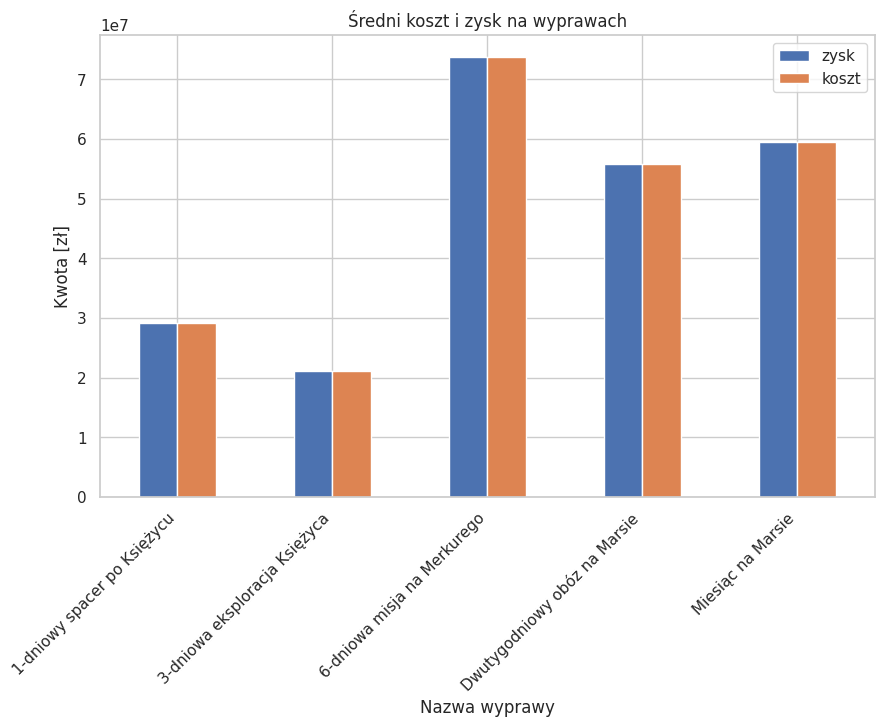

In [ ]:
zyski_koszta =  top_5_trips_kind_customers_df.join(
    top_5_trips_kind_details_df.set_index('trip_id'),
    on='trip_id',
    lsuffix='_customer',
    rsuffix='_details'
).groupby('trip_id').agg(
    _payout =('ticket_price', 'sum'),
    _cost = ('organization_cost', 'first'),
    name = ('name', 'first'),
).groupby('name').agg(
    zysk = ('_payout', 'mean'),
    koszt = ('_cost', 'mean'),
)

ax = zyski_koszta.plot.bar(
    y=['zysk', 'koszt'],
    title='Średni koszt i zysk na wyprawach',
    ylabel='Kwota [zł]',
    xlabel='Nazwa wyprawy',
    figsize=(10, 6),
)

ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right');

Widzimy, że koszt i zysk wypraw jest praktycznie ten sam.

Text(0.5, 0, '')

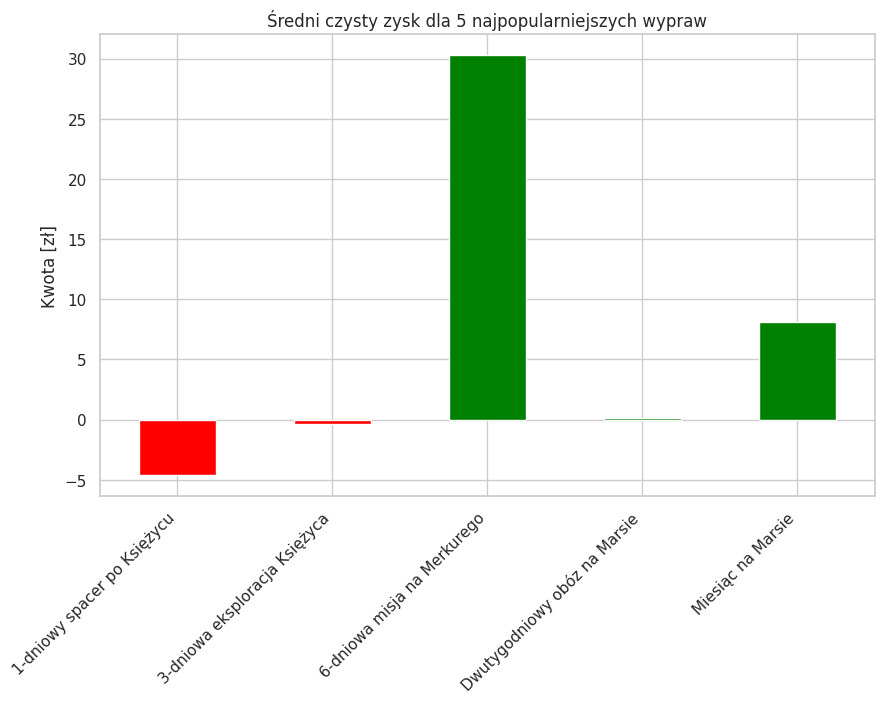

In [150]:
zyski_koszta['czysty_zysk'] = zyski_koszta['zysk'] - zyski_koszta['koszt']
colors = ['red' if x < 0 else 'green' for x in zyski_koszta['czysty_zysk']]
ax = zyski_koszta['czysty_zysk'].plot.bar(
    title='Średni czysty zysk dla 5 najpopularniejszych wypraw',
    ylabel='Kwota [zł]',

    figsize=(10, 6),
    color=colors
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right');
ax.set_xlabel(None)

Czysty zysk jest naprawdę marginalny w porównaniu z kosztami wyprawy dla 5 najpopularniejszych wypraw. Jak wygląda to w kontekście wszystkich wypraw?

In [139]:
payout_from_all_query = """
SELECT
    SUM(ticket_price) AS total_payout, Trips.trip_id, name, organization_cost
FROM
    TripParticipants
JOIN Trips ON TripParticipants.trip_id = Trips.trip_id
GROUP BY
    Trips.trip_id
"""

cursor.execute(payout_from_all_query)
payout_from_all = cursor.fetchall()
payout_from_all_df = pd.DataFrame(payout_from_all, columns=[i[0] for i in cursor.description])

In [142]:
payout_from_all_df['czysty_zysk'] = payout_from_all_df['total_payout'] - payout_from_all_df['organization_cost'].astype(float)

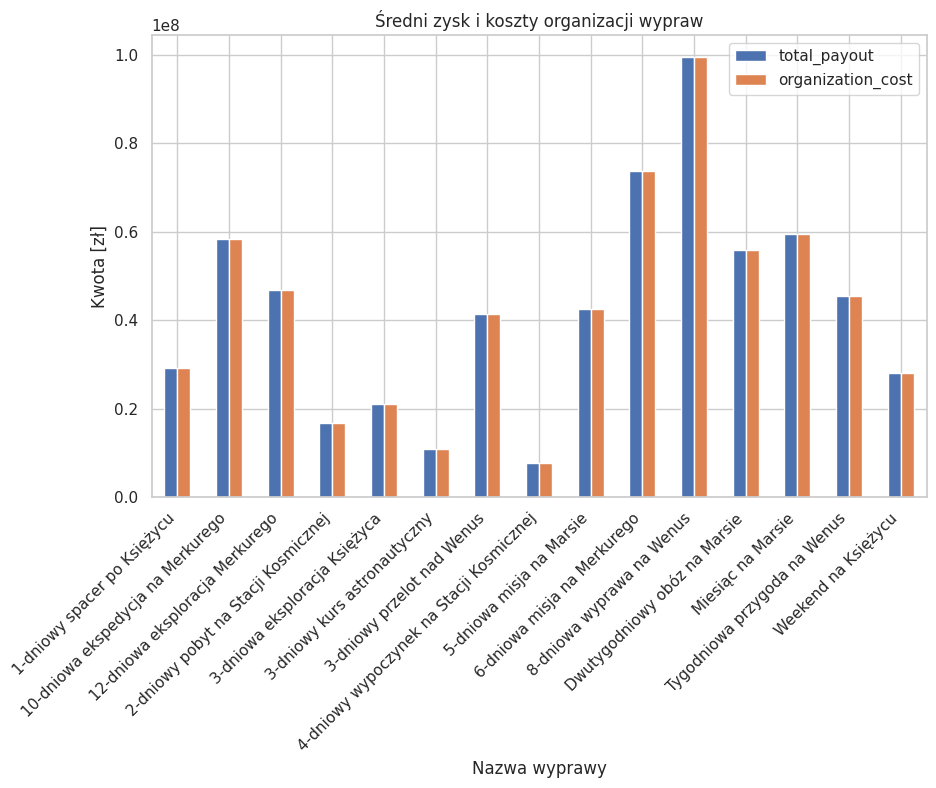

In [146]:
payout_from_all_df.groupby('name').agg(
    czysty_zysk=('czysty_zysk', 'mean'),
    total_payout=('total_payout', 'mean'),
    organization_cost=('organization_cost', 'mean'),
).plot.bar(
    y=['total_payout', 'organization_cost'],
    title='Średni zysk i koszty organizacji wypraw',
    ylabel='Kwota [zł]',
    xlabel='Nazwa wyprawy',
    figsize=(10, 6),
)
plt.xticks(rotation=45, ha='right');

Brak znaczącego zysku nie ogranicza się tylko do wcześniej wymienionych wypraw ale do **wszystkich**. Wygląda na to, że firma nie ma planów na dalsze inwestycje. W takim razie sprawdźmy czy taka strategia powoduje stratę klientów.

launch_date
2168-08-25    15.000000
2168-12-29    14.500000
2169-01-05    14.833333
2169-01-12    14.833333
2169-01-19    14.833333
                ...    
2186-01-12    15.066667
2186-01-19    15.066667
2186-01-26    15.166667
2186-02-02    15.166667
2186-02-09    14.533333
Name: participants_count, Length: 340, dtype: float64


/home/felixg/Repo/pwr/bazy-danych/Space-U/.venv/lib/python3.13/site-packages/pandas/plotting/_matplotlib/core.py:981: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  return ax.plot(*args, **kwds)
/tmp/ipykernel_54182/1293617694.py:47: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  plt.plot(


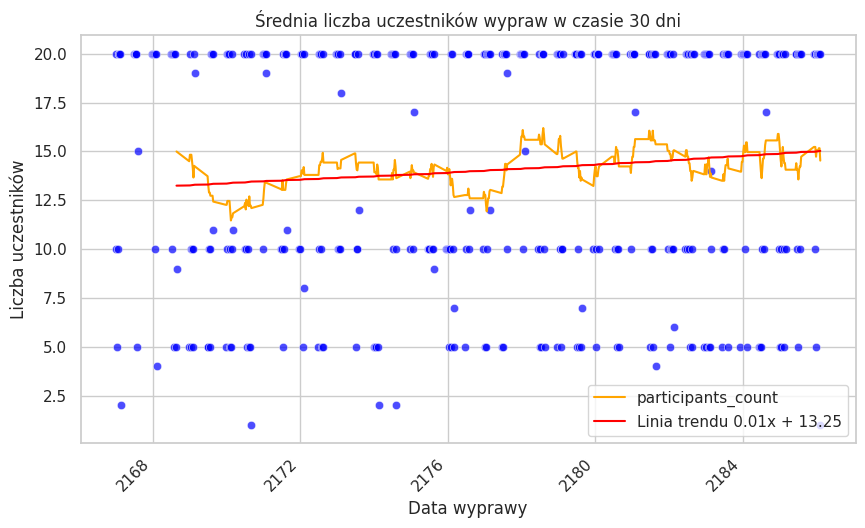

In [171]:
participants_query = """
SELECT
    COUNT(*) AS participants_count,
    launch_date
FROM
    TripParticipants
JOIN Trips ON TripParticipants.trip_id = Trips.trip_id
GROUP BY
    launch_date
ORDER BY
    launch_date
"""

cursor.execute(participants_query)
participants = cursor.fetchall()
participants_df = pd.DataFrame(participants, columns=[i[0] for i in cursor.description])
participants_df['launch_date'] = pd.to_datetime(participants_df['launch_date'])
participants_df.set_index('launch_date', inplace=True)
sns.scatterplot(
    data=participants_df,
    x=participants_df.index,
    y='participants_count',
    color='blue',
    alpha=0.7
)
plt.xticks(rotation=45, ha='right');

thirty_days_mean = participants_df['participants_count'].rolling(window=30).mean().dropna()

thirty_days_mean.plot(
    title='Średnia liczba uczestników wypraw w czasie 30 dni',
    ylabel='Liczba uczestników',
    xlabel='Data wyprawy',
    figsize=(10, 6),
    color='orange'
)
plt.xticks(rotation=45, ha='right');


print(thirty_days_mean)
a, b = stats.linregress(
    np.arange(len(thirty_days_mean)),
    thirty_days_mean
)[:2]

trendline = a * np.arange(len(thirty_days_mean)) + b
plt.plot(
    thirty_days_mean.index,
    trendline,
    color='red',
    label=f'Linia trendu {a:.2f}x + {b:.2f}'
)
plt.legend()

Liczba uczestników wypraw wacha się często pomiędzy 20, 10 i 5. Nie ma widocznych anomalii, dane są bardzo regularne. Współczynik kierunowy uzyskany przez regresje liniową $a = 0.01$ wskazuję na mały wzrost zainteresowanią firmą w ciągu lat. Czyli firma nie traci klientów, a nawet ich zyskuje! W takim wypadku pozostaje tylko zbadać które wyprawy ponownie przyciągają klientów.